In [2]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import pandas as pd

In [3]:

# Load your .mat file
data = sio.loadmat('./Results/GetResultsOnGapFilledModels.mat')
f1_medLP = data['f1_medLP'].squeeze()
f1_medMILP = data['f1_medMILP'].squeeze()
f1_ComLP = data['f1_ComLP'].squeeze()
f1_ComMILP = data['f1_ComMILP'].squeeze()
pre_medLP = data['pre_medLP'].squeeze()
pre_medMILP = data['pre_medMILP'].squeeze()
pre_ComLP = data['pre_ComLP'].squeeze()
pre_ComMILP = data['pre_ComMILP'].squeeze()
rec_medLP = data['rec_medLP'].squeeze()
rec_medMILP = data['rec_medMILP'].squeeze()
rec_ComLP = data['rec_ComLP'].squeeze()
rec_ComMILP = data['rec_ComMILP'].squeeze()


# generating a dataframe for the data
data_f1 = {
    'Model': list(range(1, len(f1_medLP) + 1)) * 4,
    'F1-score': f1_medLP.tolist() + f1_medMILP.tolist() + f1_ComLP.tolist() + f1_ComMILP.tolist(),
    'GapFillType': ['Single'] * len(f1_medLP) + ['Single'] * len(f1_medMILP) + ['Community'] * len(f1_ComLP) + ['Community'] * len(f1_ComMILP),
    'Method': ['minNetLP'] * len(f1_medLP) + ['minNetMILP'] * len(f1_medMILP) + ['minNetLP'] * len(f1_ComLP) + ['minNetMILP'] * len(f1_ComMILP)
}
data_f1 = pd.DataFrame(data_f1)

data_pre = {
    'Model': list(range(1, len(pre_medLP) + 1)) * 4,
    'Precision': pre_medLP.tolist() + pre_medMILP.tolist() + pre_ComLP.tolist() + pre_ComMILP.tolist(),
    'GapFillType': ['Single'] * len(pre_medLP) + ['Single'] * len(pre_medMILP) + ['Community'] * len(pre_ComLP) + ['Community'] * len(pre_ComMILP),
    'Method': ['minNetLP'] * len(pre_medLP) + ['minNetMILP'] * len(pre_medMILP) + ['minNetLP'] * len(pre_ComLP) + ['minNetMILP'] * len(pre_ComMILP)
}
data_pre = pd.DataFrame(data_pre)

data_rec = {
    'Model': list(range(1, len(rec_medLP) + 1)) * 4,
    'Recall': rec_medLP.tolist() + rec_medMILP.tolist() + rec_ComLP.tolist() + rec_ComMILP.tolist(),
    'GapFillType': ['Single'] * len(rec_medLP) + ['Single'] * len(rec_medMILP) + ['Community'] * len(rec_ComLP) + ['Community'] * len(rec_ComMILP),
    'Method': ['minNetLP'] * len(rec_medLP) + ['minNetMILP'] * len(rec_medMILP) + ['minNetLP'] * len(rec_ComLP) + ['minNetMILP'] * len(rec_ComMILP)
}
data_rec = pd.DataFrame(data_rec)

In [3]:
def plot_half_violin(ax, df, metric, pal, yticks=np.arange(0, 0.8, 0.2),legend=False,xlabel=False):
    sns.violinplot(y=metric,x = 'Method',hue='GapFillType',split=True,gap=0.3,data=df,ax=ax,inner="quart",palette=pal)
    ax.set_title(metric,fontsize=30,fontweight='bold')
    # making the spines off
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_ylabel('',fontsize=1,fontweight='bold')
    # setting the ylim
    ax.set_ylim(0,0.7)
    if xlabel:
        ax.set_xlabel('Network Inference Method',fontsize=20,fontweight='bold')
    else:
        ax.set_xlabel('')

    # making the ticlabels bold
    ax.set_xticklabels(ax.get_xticklabels(),fontsize=30)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ax.get_yticklabels(),fontsize=30)

    # getting the count of unique df['Model']
    models = df['Model'].unique()

    # getting the xticks location
    xticks = [tick.get_position()[0] for tick in ax.get_xticklabels()]
    # making a slope plot
    scale = 0.06
    count_of_higher = {'lp_single':0,'lp_community':0,'milp_single':0,'milp_community':0}
    for m in models:
        df1 = df[(df['Model']==m)&(df['Method']=='minNetLP')]
        ax.scatter([xticks[0]-scale],df1[df1['GapFillType']=='Single'][metric],color=pal['Single'],s=20)
        ax.scatter([xticks[0]+scale],df1[df1['GapFillType']=='Community'][metric],color=pal['Community'],s=20)
        ax.plot([xticks[0]-0.06,xticks[0]+0.06],[df1[df1['GapFillType']=='Single'][metric],df1[df1['GapFillType']=='Community'][metric]],'-',color='k',linewidth=0.5)

        df2 = df[(df['Model']==m)&(df['Method']=='minNetMILP')]
        ax.scatter([xticks[1]-scale],df2[df2['GapFillType']=='Single'][metric],color=pal['Single'],s=20)
        ax.scatter([xticks[1]+scale],df2[df2['GapFillType']=='Community'][metric],color=pal['Community'],s=20)
        ax.plot([xticks[1]-0.06,xticks[1]+0.06],[df2[df2['GapFillType']=='Single'][metric],df2[df2['GapFillType']=='Community'][metric]],'-',color='k',linewidth=0.5)

        if df1[df1['GapFillType']=='Single'][metric].values < df1[df1['GapFillType']=='Community'][metric].values:
            count_of_higher['lp_community'] += 1
        else:
            count_of_higher['lp_single'] += 1
        if df2[df2['GapFillType']=='Single'][metric].values < df2[df2['GapFillType']=='Community'][metric].values:
            count_of_higher['milp_community'] += 1
        else:
            count_of_higher['milp_single'] += 1
    if legend:
        ax.legend(fontsize=35,loc='upper center', bbox_to_anchor=(-.75, -0.15),
          ncol=2, frameon=False)
        # ax.legend(title='GapFillType',title_fontsize=25,loc='upper right',fontsize=16,title_fontsize=18)
    else:
        ax.get_legend().remove()

    return count_of_higher

C:\Users\Admin\AppData\Local\Temp\ipykernel_30548\242198035.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=30)
C:\Users\Admin\AppData\Local\Temp\ipykernel_30548\242198035.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=30)
C:\Users\Admin\AppData\Local\Temp\ipykernel_30548\242198035.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=30)


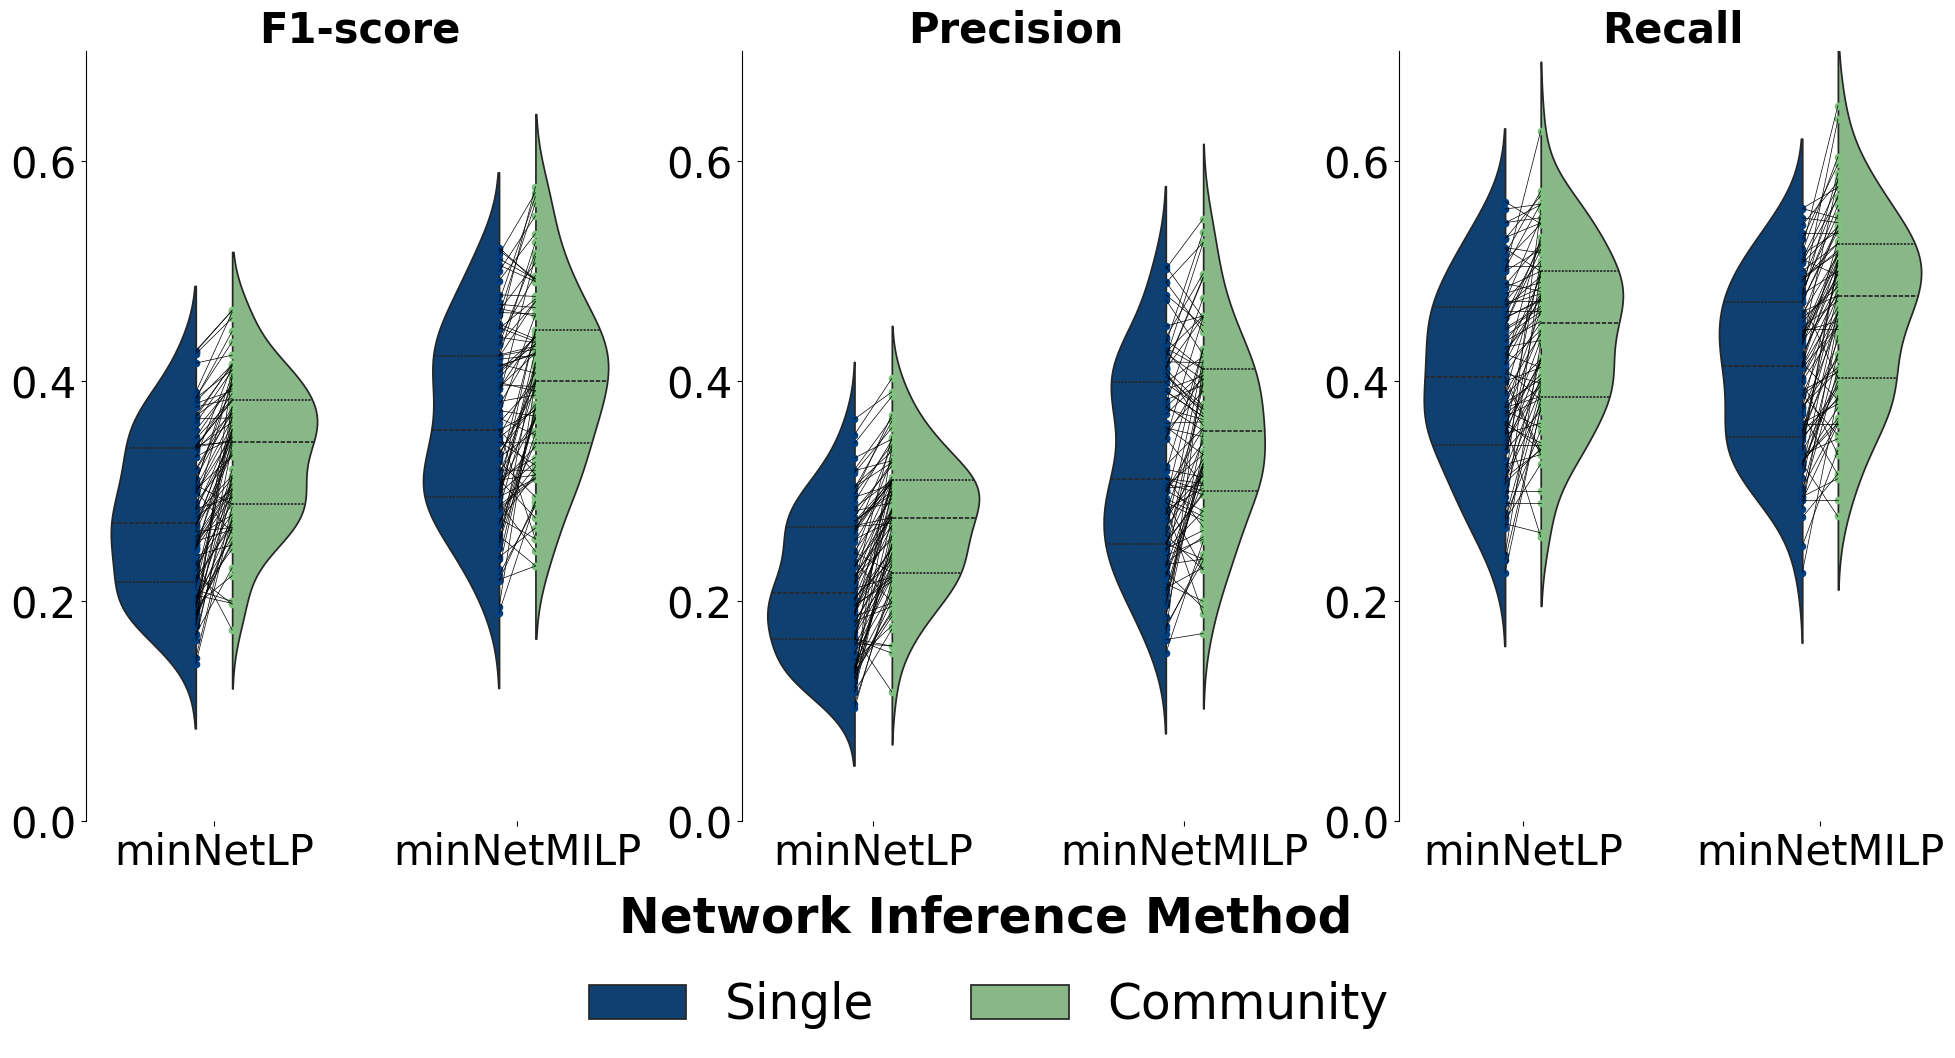

In [4]:
fig,ax = plt.subplots(1,3,figsize=(24,10))
ax = ax.flatten()
pal={'Single':'#004080','Community':'#80c080'}
count_of_higher_f1 = plot_half_violin(ax[0], data_f1, 'F1-score', pal)
count_of_higher_pre = plot_half_violin(ax[1], data_pre, 'Precision', pal)
count_of_higher_rec = plot_half_violin(ax[2], data_rec, 'Recall', pal,legend=True)
# setting the xlabel for the figure
fig.text(0.5, 0, 'Network Inference Method', ha='center', fontdict=
         {'fontsize':35,'fontweight':'bold'})
plt.savefig('./hcom_gapfill_performance.png',bbox_inches='tight',dpi=300)

In [5]:
# running wilcoxon signed rank test
from scipy.stats import wilcoxon

print('For the case of minNetLP- F1 score')
res = wilcoxon(f1_ComLP.astype(np.float32), f1_medLP.astype(np.float32), alternative='greater')
print(res.pvalue)

print('For the case of minNetMILP- F1 score')
res = wilcoxon(f1_ComMILP.astype(np.float32), f1_medMILP.astype(np.float32), alternative='greater')
print(res.pvalue)

print('For the case of minNetLP - precision')
res = wilcoxon(pre_ComLP.astype(np.float32), pre_medLP.astype(np.float32), alternative='greater')
print(res.pvalue)

print('For the case of minNetMILP-precision')
res = wilcoxon(pre_ComMILP.astype(np.float32), pre_medMILP.astype(np.float32), alternative='greater')
print(res.pvalue)

print('For the case of minNetLP - recall')
res = wilcoxon(rec_ComLP.astype(np.float32), rec_medLP.astype(np.float32), alternative='greater')
print(res.pvalue)

print('For the case of minNetMILP-recall')
res = wilcoxon(rec_ComMILP.astype(np.float32), rec_medMILP.astype(np.float32), alternative='greater')
print(res.pvalue)

For the case of minNetLP- F1 score
2.3687291490818403e-15
For the case of minNetMILP- F1 score
1.290757542281744e-09
For the case of minNetLP - precision
6.703945666761071e-16
For the case of minNetMILP-precision
2.7563717933559265e-05
For the case of minNetLP - recall
6.159232538071586e-11
For the case of minNetMILP-recall
2.4630577789099813e-13
